In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300


In [148]:
chopTFs_seq_df =pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/ChopYeastTFsDesign.csv").drop(columns = ["ArrayDNA"])
#chopTFs_seq_df = chopTFs_seq_df[["SpeciesName", "Seq", "Length"]]
chopTFs_seq_df["id"] = chopTFs_seq_df["Name"].str.split("|").str[1].str.split("_").str[0]
chopTFs_seq_df["gene"] = chopTFs_seq_df["Name"].str.split("|").str[0]
chopTFs_seq_df["tile_start"] = chopTFs_seq_df["Name"].str.split("_").str[-1]
chopTFs_seq_df

,Unnamed: 0,ADseq,Name,id,gene,tile_start
0,0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,OAF1|YAL051W_1,YAL051W,OAF1,1
1,1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,OAF1|YAL051W_6,YAL051W,OAF1,6
2,2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,OAF1|YAL051W_11,YAL051W,OAF1,11
3,3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,OAF1|YAL051W_16,YAL051W,OAF1,16
4,4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,OAF1|YAL051W_21,YAL051W,OAF1,21
...,...,...,...,...,...,...
18838,47,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,Gnc4Lib_Kappa_HIGH_0,NaN,Gnc4Lib_Kappa_HIGH_0,0
18839,48,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,Gnc4Lib_Disorder_HIGH_0,NaN,Gnc4Lib_Disorder_HIGH_0,0
18840,49,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,Gnc4Lib_Disorder_HIGH_0,NaN,Gnc4Lib_Disorder_HIGH_0,0
18841,50,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,Gnc4Lib_Charge_HIGH_0,NaN,Gnc4Lib_Charge_HIGH_0,0


In [149]:
TF_len = pd.DataFrame(chopTFs_seq_df.groupby("gene")["tile_start"].max()).reset_index().rename(columns = {"tile_start" : "max_tile_start"})
TF_len["len"] = TF_len["max_tile_start"].astype(int) + 40
TF_len

,gene,max_tile_start,len
0,ABF1,96,136
1,ACA1,96,136
2,ACE2,96,136
3,ADR1,996,1036
4,AFT1,96,136
...,...,...,...
513,ZAP1_86,86,126
514,ZAP1_91,91,131
515,ZAP1_96,96,136
516,nan,996,1036


In [150]:
chopTFs_seq_df = pd.merge(chopTFs_seq_df, TF_len)
chopTFs_seq_df = chopTFs_seq_df.dropna()
chopTFs_seq_df

,Unnamed: 0,ADseq,Name,id,gene,tile_start,max_tile_start,len
0,0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,OAF1|YAL051W_1,YAL051W,OAF1,1,996,1036
1,1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,OAF1|YAL051W_6,YAL051W,OAF1,6,996,1036
2,2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,OAF1|YAL051W_11,YAL051W,OAF1,11,996,1036
3,3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,OAF1|YAL051W_16,YAL051W,OAF1,16,996,1036
4,4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,OAF1|YAL051W_21,YAL051W,OAF1,21,996,1036
...,...,...,...,...,...,...,...,...
18412,18413,KLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDL,nan|YPR196W_411,YPR196W,nan,411,996,1036
18413,18414,NILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRP,nan|YPR196W_416,YPR196W,nan,416,996,1036
18414,18415,VSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLND,nan|YPR196W_421,YPR196W,nan,421,996,1036
18415,18416,FSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLNDDSKDE,nan|YPR196W_426,YPR196W,nan,426,996,1036


In [151]:
chopTFs_speeds = pd.read_csv("../../../output/ChopTFs_pipeline/speed/exponential_fit.csv", index_col = 0)[["ADseq", "A*k"]]
chopTFs_speeds

,ADseq,A*k
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.311517
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,0.215549
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,0.197152
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,0.105899
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,0.177181
...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,0.146181
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,0.089777
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,0.177979
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,0.105664


In [165]:
def get_all_starts(full_seq, tile):
    starts = []
    start = 0
    while True:
        pos = full_seq.find(tile, start)
        if pos == -1:
            break
        starts.append(pos)
        start = pos + 1
    return starts

import re

def get_gene_stats(gene_chopTFs_seq_df, chopTFs_speeds):
    matching = gene_chopTFs_seq_df.merge(chopTFs_speeds, on='ADseq', how='inner')
    
    if matching.empty:
        return pd.Series({
            'max_speed':       None,
            'mean_speed':      None,
            'median_speed':    None,
            'top3_mean_speed': None,
            'speed_std':       None,
            'tile_count':      0,
            'coverage_fraction': 0.0
        })
    
    covered = set()
    for _, row in matching.iterrows():
        tile_len = len(row['ADseq'])
        pos = int(row['tile_start'])  # cast to int
        covered.update(range(pos, pos + tile_len))
    
    tile_len = len(matching.iloc[0]['ADseq'])
    total_span = int(matching['len'].iloc[0]) + tile_len  # cast here too
    
    speeds = matching['A*k']
    
    return pd.Series({
        'max_speed':       speeds.max(),
        'mean_speed':      speeds.mean(),
        'median_speed':    speeds.median(),
        'top3_mean_speed': speeds.nlargest(3).mean(),
        'speed_std':       speeds.std(),
        'tile_count':      len(matching),
        'coverage_fraction': len(covered) / total_span
    })

gene_stats_df = (
    chopTFs_seq_df.groupby('gene')
    .apply(lambda g: get_gene_stats(g, chopTFs_speeds))
    .reset_index()
)

In [166]:
gene_stats_df

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.098526,0.072474,0.072233,0.080998,0.025473,4.0,0.511364
1,ACA1,0.124043,0.077399,0.062959,0.077399,0.041361,3.0,0.681818
2,ACE2,0.307148,0.231297,0.212211,0.260746,0.052500,5.0,0.625000
3,ADR1,0.313974,0.183478,0.169460,0.288679,0.066846,21.0,0.329926
4,AFT1,0.274366,0.148455,0.111579,0.264156,0.082009,15.0,1.051136
...,...,...,...,...,...,...,...,...
150,YHP1,NaN,NaN,NaN,NaN,NaN,0.0,0.000000
151,YOX1,NaN,NaN,NaN,NaN,NaN,0.0,0.000000
152,YRM1,0.246965,0.126631,0.109905,0.216403,0.068120,14.0,1.505682
153,YRR1,0.206124,0.121082,0.096525,0.191026,0.054817,10.0,0.994318


In [167]:
gene_stats_df_with_max_speeds = gene_stats_df.dropna()
gene_stats_df_with_max_speeds

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.098526,0.072474,0.072233,0.080998,0.025473,4.0,0.511364
1,ACA1,0.124043,0.077399,0.062959,0.077399,0.041361,3.0,0.681818
2,ACE2,0.307148,0.231297,0.212211,0.260746,0.052500,5.0,0.625000
3,ADR1,0.313974,0.183478,0.169460,0.288679,0.066846,21.0,0.329926
4,AFT1,0.274366,0.148455,0.111579,0.264156,0.082009,15.0,1.051136
...,...,...,...,...,...,...,...,...
144,XBP1,0.113920,0.080594,0.081944,0.097010,0.021330,6.0,0.795455
145,YAP1,0.238538,0.148106,0.148820,0.207902,0.043960,13.0,1.250000
152,YRM1,0.246965,0.126631,0.109905,0.216403,0.068120,14.0,1.505682
153,YRR1,0.206124,0.121082,0.096525,0.191026,0.054817,10.0,0.994318


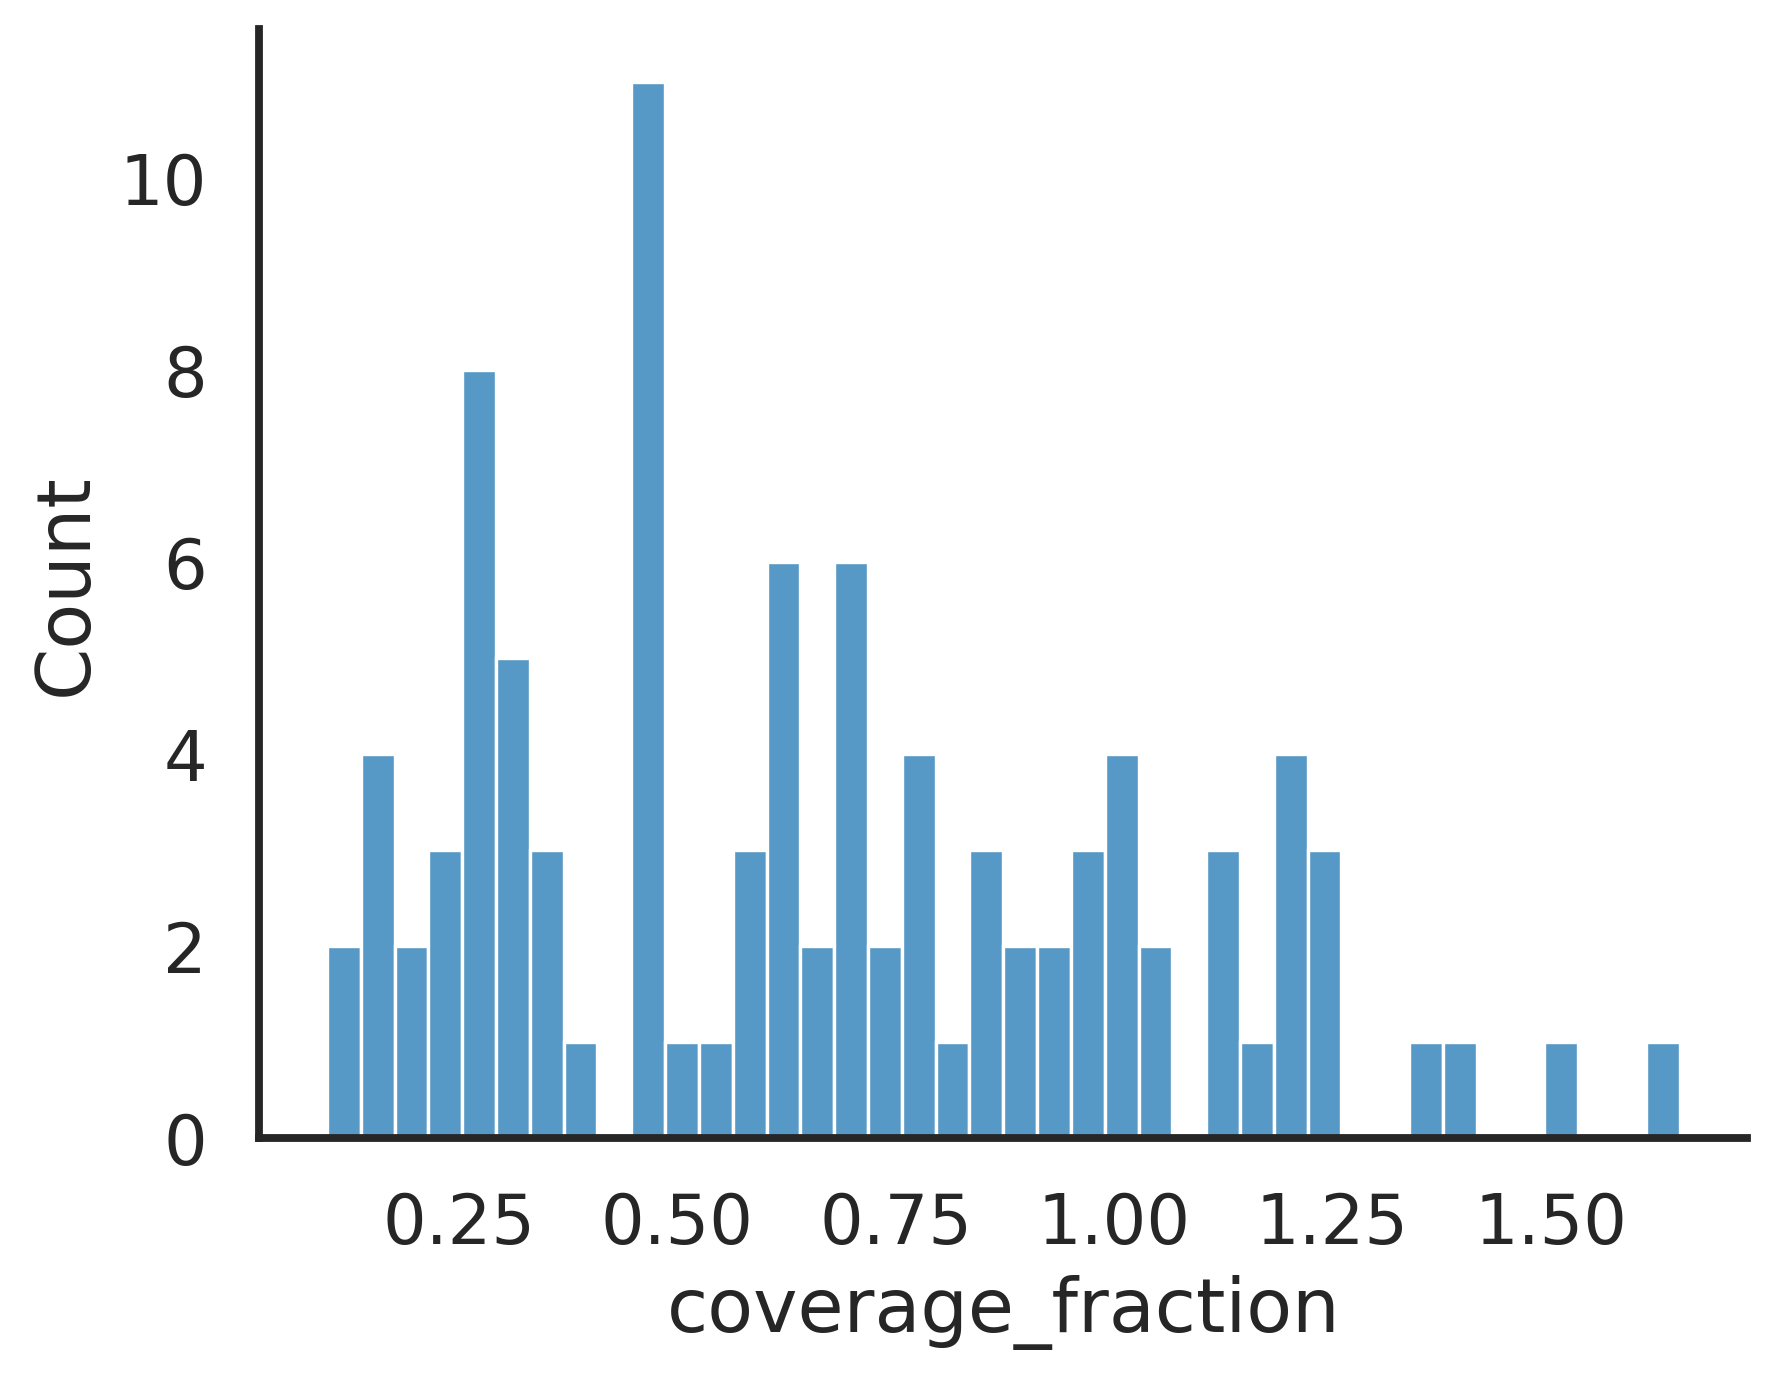

In [168]:
sns.histplot(gene_stats_df_with_max_speeds["coverage_fraction"], bins=40)
sns.despine()

In [169]:
gene_stats_df_with_max_speeds_suffic_cov = gene_stats_df_with_max_speeds[gene_stats_df_with_max_speeds["coverage_fraction"] >= 0.5]
gene_stats_df_with_max_speeds_suffic_cov

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.098526,0.072474,0.072233,0.080998,0.025473,4.0,0.511364
1,ACA1,0.124043,0.077399,0.062959,0.077399,0.041361,3.0,0.681818
2,ACE2,0.307148,0.231297,0.212211,0.260746,0.052500,5.0,0.625000
4,AFT1,0.274366,0.148455,0.111579,0.264156,0.082009,15.0,1.051136
5,AFT2,0.285980,0.182043,0.172565,0.238330,0.057994,8.0,0.823864
6,ARO80,0.277971,0.174005,0.182106,0.238387,0.068629,8.0,0.852273
7,ASG1,0.181400,0.107360,0.100989,0.154521,0.055203,6.0,1.011364
10,BAS1,0.171114,0.099415,0.075462,0.118241,0.042971,5.0,0.738636
14,CEP3,0.253292,0.106945,0.088012,0.174730,0.059595,10.0,1.193182
15,CHA4,0.356571,0.142549,0.113780,0.267778,0.088127,12.0,0.965909


Text(0.5, 0.98, 'ChopTFs Full TF Speed Aggregation')

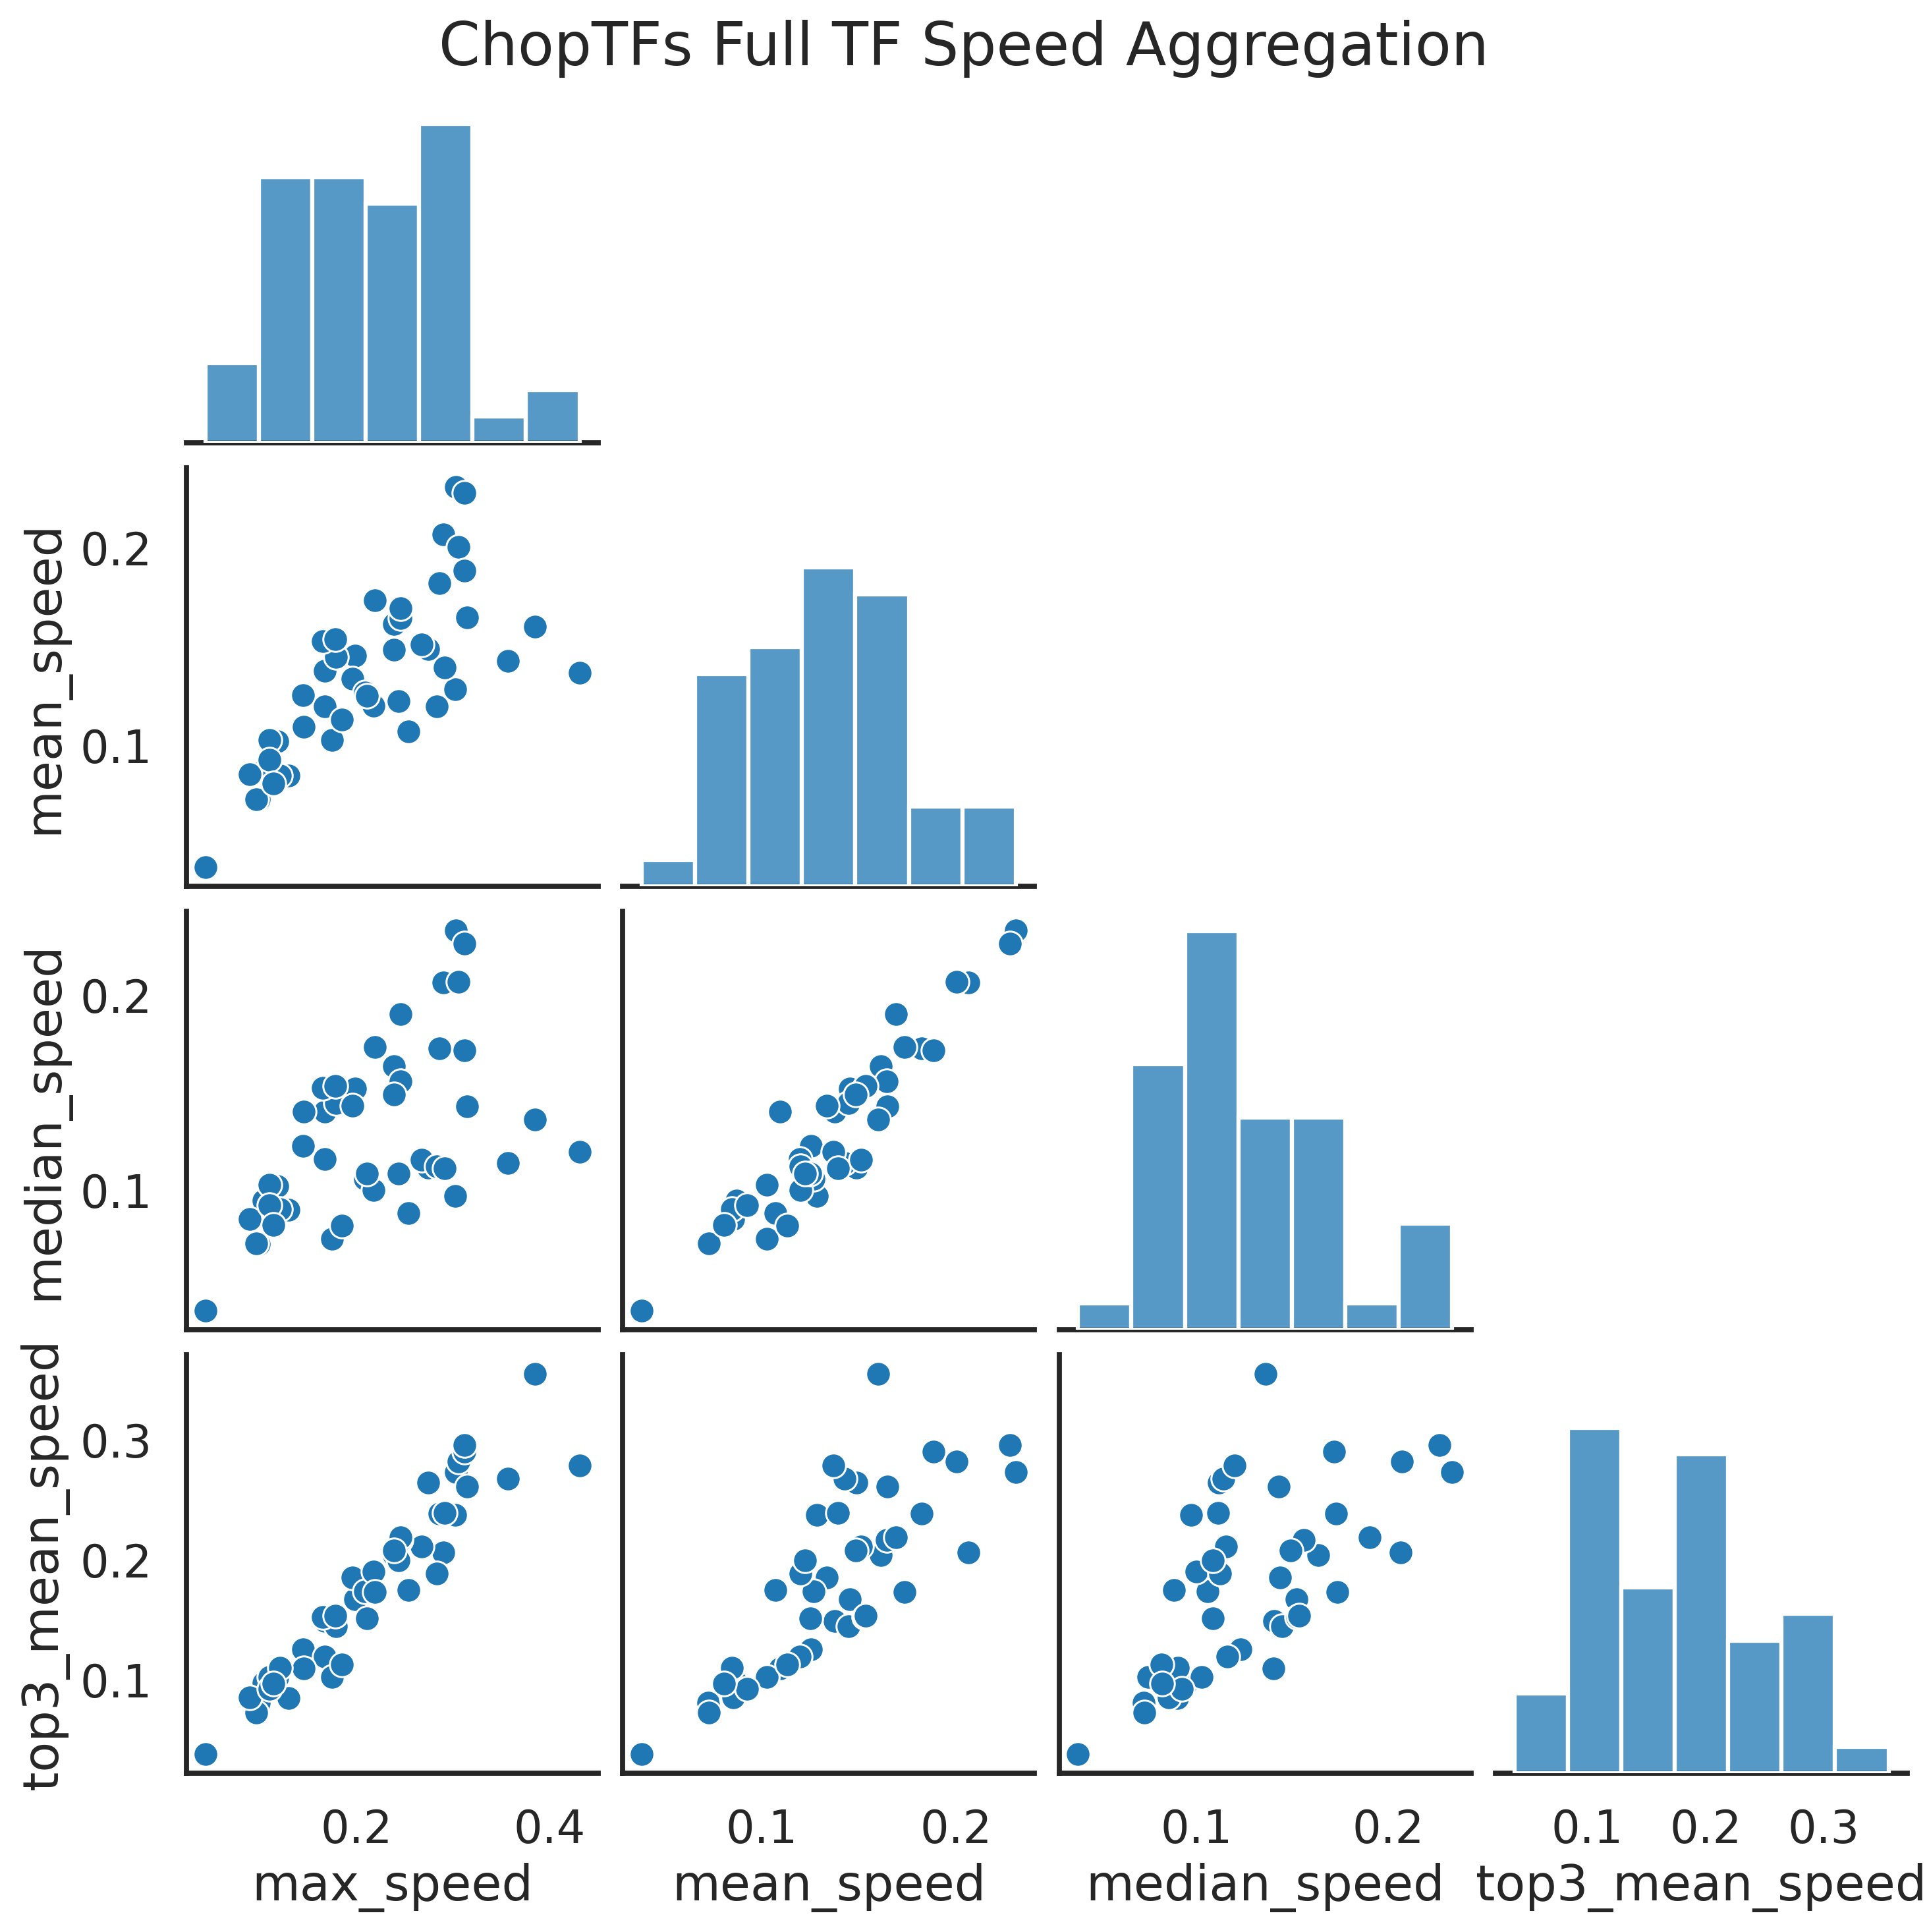

In [95]:
sns.set_context('talk')
sns.set_style('white')
sns.pairplot(gene_stats_df_with_max_speeds_suffic_cov[["max_speed", "mean_speed", "median_speed", "top3_mean_speed"]],
            corner=True)
plt.suptitle("ChopTFs Full TF Speed Aggregation")

In [96]:
gene_stats_df_with_max_speeds_suffic_cov

,gene,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,coverage_fraction
0,ABF1,0.098526,0.072474,0.072233,0.080998,0.025473,4.0,0.900000
4,AFT1,0.274366,0.148455,0.111579,0.264156,0.082009,15.0,0.755102
5,AFT2,0.285980,0.182043,0.172565,0.238330,0.057994,8.0,0.580000
11,CAD1,0.198272,0.145121,0.152022,0.167438,0.049813,4.0,1.000000
14,CEP3,0.253292,0.106945,0.088012,0.174730,0.059595,10.0,0.736842
15,CHA4,0.356571,0.142549,0.113780,0.267778,0.088127,12.0,0.539683
18,COM2,0.042973,0.038034,0.038034,0.038034,0.006985,2.0,0.941176
19,CRZ1,0.302336,0.128168,0.097103,0.237701,0.076011,13.0,0.571429
20,CSE4,0.117573,0.101893,0.101893,0.101893,0.022174,2.0,1.000000
21,CST6,0.144677,0.125364,0.122683,0.125364,0.018122,3.0,1.000000


In [101]:
threshold = gene_stats_df['top3_mean_speed'].quantile(0.8)

# gene lists
fast_genes = gene_stats_df[gene_stats_df['top3_mean_speed'] >= threshold]['gene'].tolist()
all_tested = gene_stats_df['gene'].tolist()  # background

# save to txt files for upload
with open('../../../output/ChopTFs_pipeline/speed/fast_genes.txt', 'w') as f:
    f.write('\n'.join(fast_genes))

with open('../../../output/ChopTFs_pipeline/speed/background.txt', 'w') as f:
    f.write('\n'.join(all_tested))